In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/DailyDelhiClimateTrain.csv")

In [ ]:
print(data.head())
print(data.tail())
print(data.info())
print(data.describe())
print(data.isnull().sum())

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
            date   meantemp    humidity  wind_speed  meanpressure
1457  2016-12-28  17.217391   68.043478    3.547826   1015.565217
1458  2016-12-29  15.238095   87.857143    6.000000   1016.904762
1459  2016-12-30  14.095238   89.666667    6.266667   1017.904762
1460  2016-12-31  15.052632   87.000000    7.325000   1016.100000
1461  2017-01-01  10.000000  100.000000    0.000000   1016.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   objec

In [ ]:
figure=px.line(data,x="date",y="meantemp",title="Mean Temperature in Delhi")
figure.show()

In [ ]:
figure=px.line(data,x="date",y="humidity",title="Humidity in Delhi")
figure.show()

In [ ]:
figure=px.line(data,x="date",y="wind_speed",title="Speed of Wind in Delhi")
figure.show()

In [ ]:
figure=px.scatter(data_frame=data,x='humidity',y='meantemp',size='meantemp',trendline='ols',title='Humidity vs Mean Temperature')
figure.show()

In [ ]:
data['date']=pd.to_datetime(data['date'],format='%Y-%m-%d')
data['year']=data['date'].dt.year
data['month']=data['date'].dt.month
print(data.head())

        date   meantemp   humidity  wind_speed  meanpressure  year  month
0 2013-01-01  10.000000  84.500000    0.000000   1015.666667  2013      1
1 2013-01-02   7.400000  92.000000    2.980000   1017.800000  2013      1
2 2013-01-03   7.166667  87.000000    4.633333   1018.666667  2013      1
3 2013-01-04   8.666667  71.333333    1.233333   1017.166667  2013      1
4 2013-01-05   6.000000  86.833333    3.700000   1016.500000  2013      1


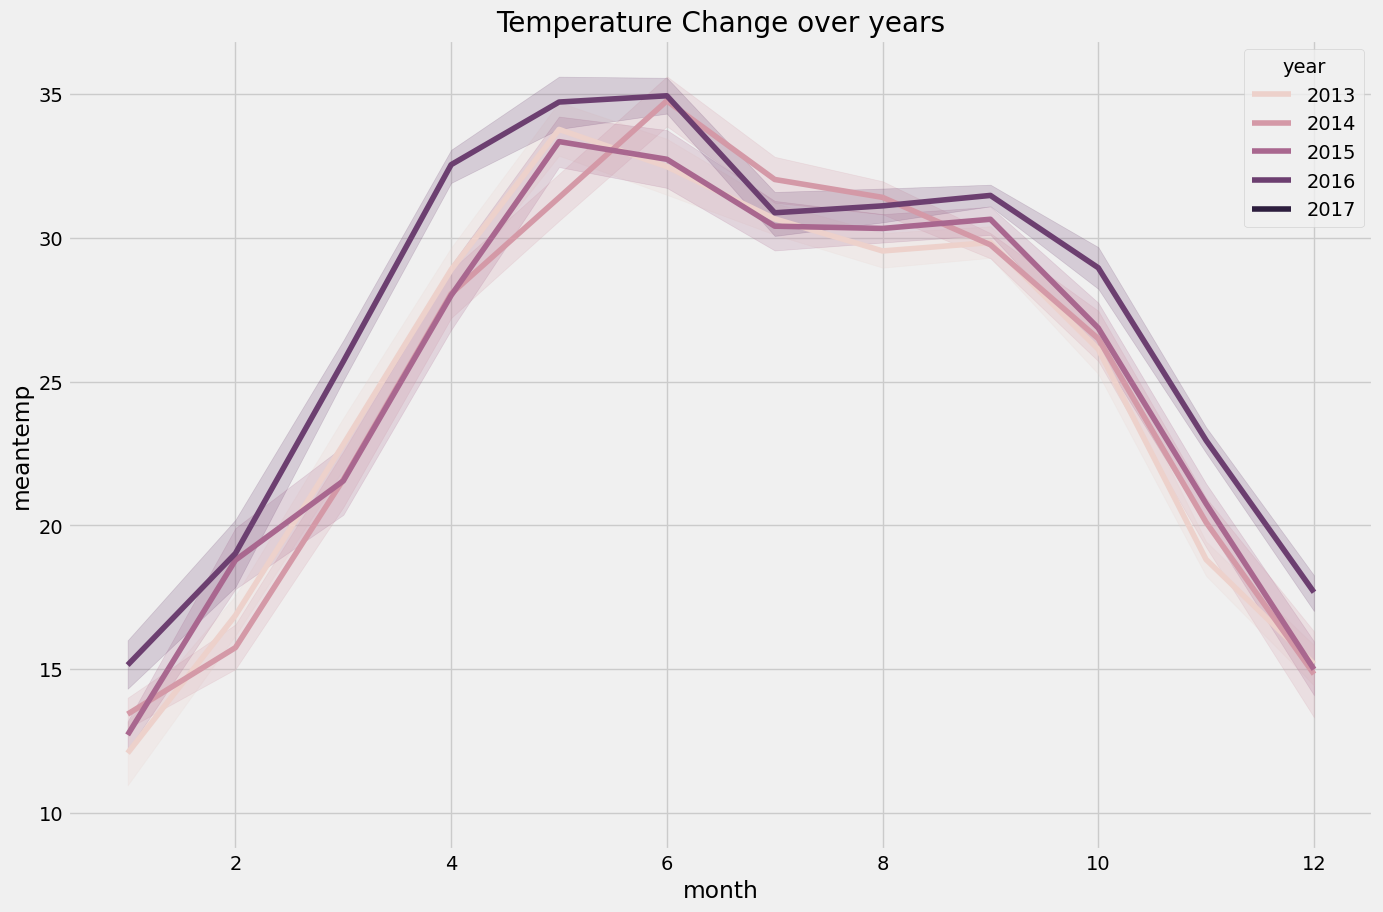

In [ ]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15,10))
plt.title("Temperature Change over years")
sns.lineplot(data=data,x='month',y='meantemp',hue='year')
plt.show()

In [ ]:
!pip install prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


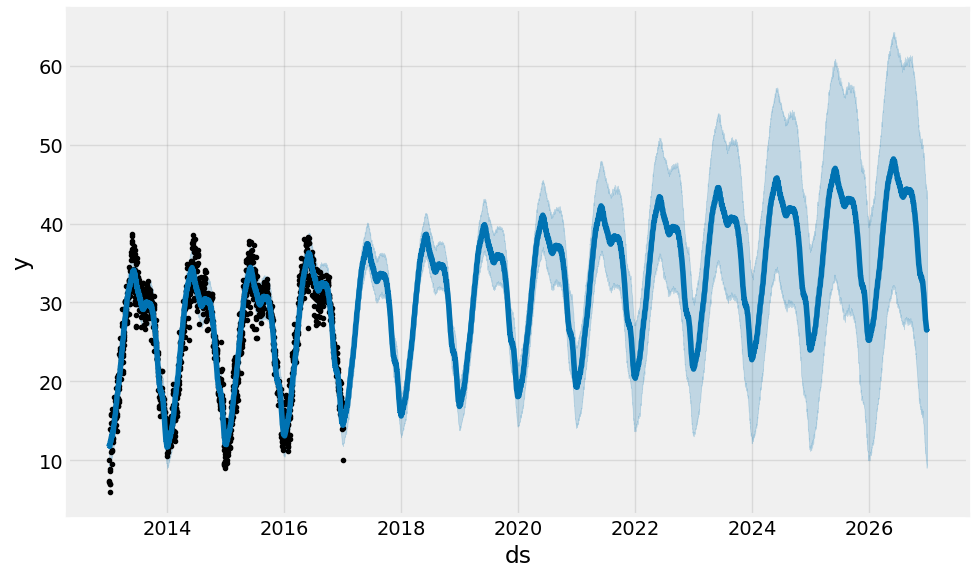

In [ ]:
from prophet import Prophet
forecast_data=data.rename(columns={'date':'ds','meantemp':'y'})
forecast_data=forecast_data[['ds','y']]
forecast_data['ds']=pd.to_datetime(forecast_data['ds'])
forecast_data['y']=pd.to_numeric(forecast_data['y'],errors='coerce')
forecast_data=forecast_data.dropna()
model=Prophet()
model.fit(forecast_data)
forecasts=model.make_future_dataframe(periods=3650)
predictions=model.predict(forecasts)

from prophet.plot import plot
fig=plot(model,predictions)
fig.show()